---

# JOINING DATAFRAMES

---

<br><br>

>---
>You can **Join DataFrames** with the `.merge()` method
>
>- The DataFrames must share at least one column to match the values between them
>
>---

<br>

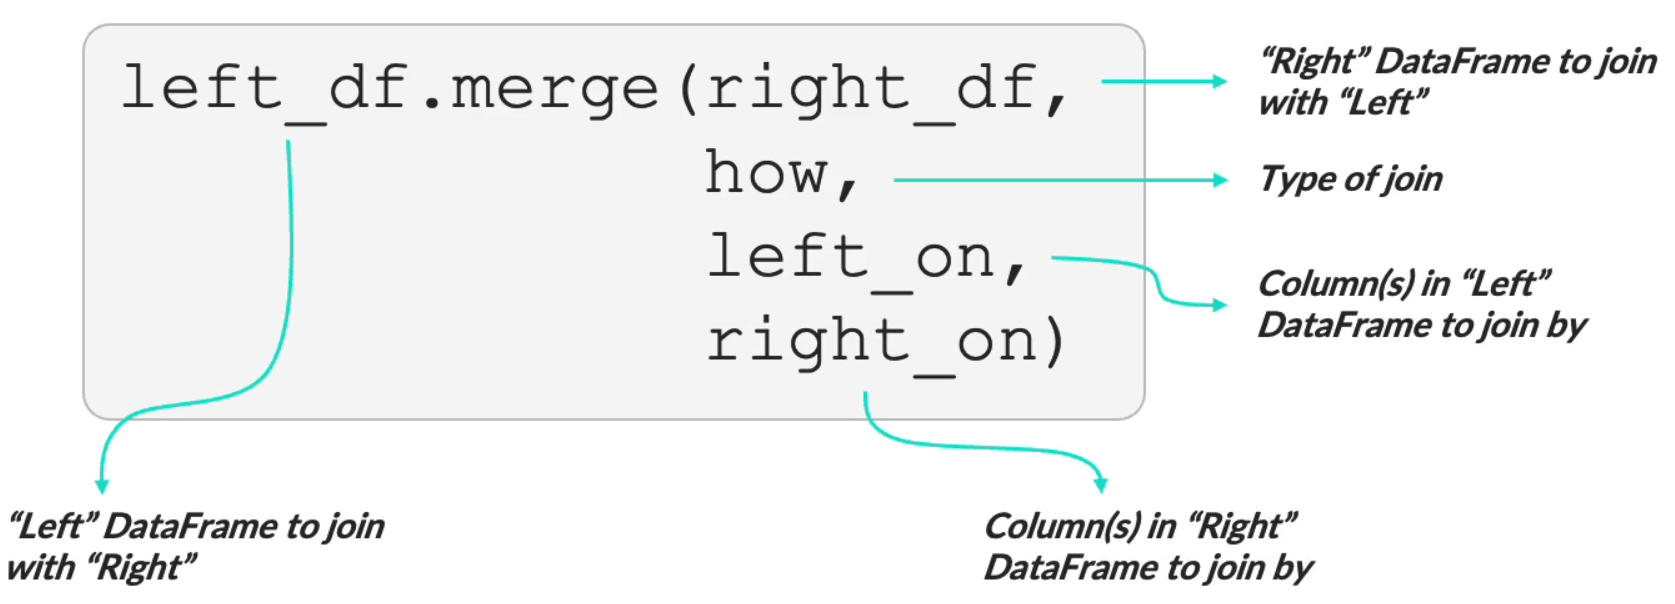

<br>

In [2]:
import numpy as np
import pandas as pd

In [8]:
df1 = pd.read_parquet('../Data/retail_2016_2017.parquet')

df2 = pd.read_parquet('../Data/transactions.parquet')

display(df1, df2)

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0
1,1945945,2016-01-01,1,BABY CARE,0.000,0
2,1945946,2016-01-01,1,BEAUTY,0.000,0
3,1945947,2016-01-01,1,BEVERAGES,0.000,0
4,1945948,2016-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
1054939,3000883,2017-08-15,9,POULTRY,438.133,0
1054940,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
1054941,3000885,2017-08-15,9,PRODUCE,2419.729,148
1054942,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
83483,2017-08-15,50,2804
83484,2017-08-15,51,1573
83485,2017-08-15,52,2255
83486,2017-08-15,53,932


<br><br>

---

## 1. Workging with `right_on=` and `left_on=`

<br>

In [15]:
new_df = df1.merge(df2, 
          right_on=['date', 'store_nbr'], 
          left_on=['date', 'store_nbr'],
         )
new_df

,id,date,store_nbr,family,sales,onpromotion,transactions
0,1947957,2016-01-02,16,AUTOMOTIVE,8.000,0,373
1,1947958,2016-01-02,16,BABY CARE,0.000,0,373
2,1947959,2016-01-02,16,BEAUTY,0.000,0,373
3,1947960,2016-01-02,16,BEVERAGES,1533.000,0,373
4,1947961,2016-01-02,16,BOOKS,0.000,0,373
...,...,...,...,...,...,...,...
1026163,3000883,2017-08-15,9,POULTRY,438.133,0,2155
1026164,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155
1026165,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155
1026166,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155


In [16]:
new_df.isna().sum()

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
transactions    0
dtype: int64

<br><br>

---

## 2. Workging with `on=` and `how='inner'`

<br>

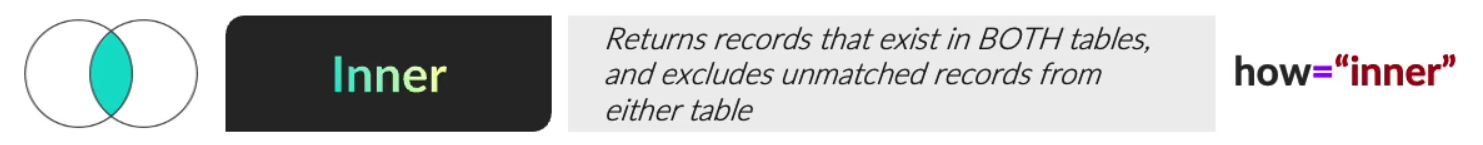

<br>

In [19]:
new_df = df1.merge(df2, 
         on=['date', 'store_nbr'],
         how='inner'
         )
new_df

,id,date,store_nbr,family,sales,onpromotion,transactions
0,1947957,2016-01-02,16,AUTOMOTIVE,8.000,0,373
1,1947958,2016-01-02,16,BABY CARE,0.000,0,373
2,1947959,2016-01-02,16,BEAUTY,0.000,0,373
3,1947960,2016-01-02,16,BEVERAGES,1533.000,0,373
4,1947961,2016-01-02,16,BOOKS,0.000,0,373
...,...,...,...,...,...,...,...
1026163,3000883,2017-08-15,9,POULTRY,438.133,0,2155
1026164,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155
1026165,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155
1026166,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155


In [20]:
new_df.isna().sum()

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
transactions    0
dtype: int64

<br><br>

---

## 3. Workging with `on=` and `how='left'`

<br>

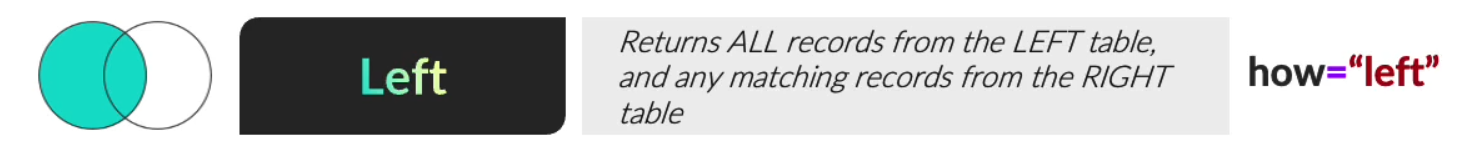

<br>

In [21]:
new_df = df1.merge(df2, 
         on=['date', 'store_nbr'],
         how='left'
         )
new_df

,id,date,store_nbr,family,sales,onpromotion,transactions
0,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0,NaN
1,1945945,2016-01-01,1,BABY CARE,0.000,0,NaN
2,1945946,2016-01-01,1,BEAUTY,0.000,0,NaN
3,1945947,2016-01-01,1,BEVERAGES,0.000,0,NaN
4,1945948,2016-01-01,1,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
1054939,3000883,2017-08-15,9,POULTRY,438.133,0,2155.0
1054940,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,2155.0
1054941,3000885,2017-08-15,9,PRODUCE,2419.729,148,2155.0
1054942,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,2155.0


In [22]:
new_df.isna().sum()

id                  0
date                0
store_nbr           0
family              0
sales               0
onpromotion         0
transactions    28776
dtype: int64

<br><br>

---

## 4. Workging with `on=` and `how='right'`

<br>

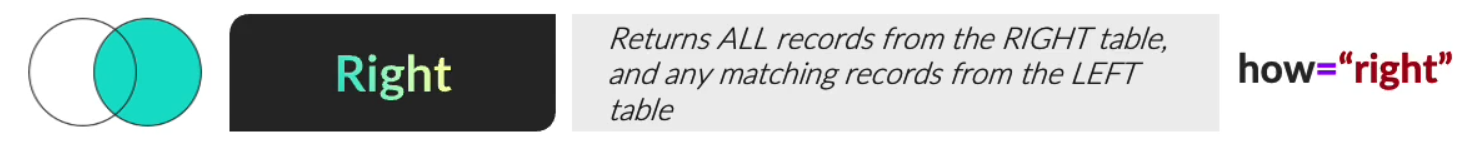

<br>

In [23]:
new_df = df1.merge(df2, 
         on=['date', 'store_nbr'],
         how='right'
         )
new_df

,id,date,store_nbr,family,sales,onpromotion,transactions
0,NaN,2013-01-01,25,NaN,NaN,NaN,770
1,NaN,2013-01-02,1,NaN,NaN,NaN,2111
2,NaN,2013-01-02,2,NaN,NaN,NaN,2358
3,NaN,2013-01-02,3,NaN,NaN,NaN,3487
4,NaN,2013-01-02,4,NaN,NaN,NaN,1922
...,...,...,...,...,...,...,...
1078555,3000751.0,2017-08-15,54,POULTRY,59.619,0.0,802
1078556,3000752.0,2017-08-15,54,PREPARED FOODS,94.000,0.0,802
1078557,3000753.0,2017-08-15,54,PRODUCE,915.371,76.0,802
1078558,3000754.0,2017-08-15,54,SCHOOL AND OFFICE SUPPLIES,0.000,0.0,802


In [24]:
new_df.isna().sum()

id              52392
date                0
store_nbr           0
family          52392
sales           52392
onpromotion     52392
transactions        0
dtype: int64

<br><br>

---

## 5. Workging with `on=` and `how='outer'`

<br>

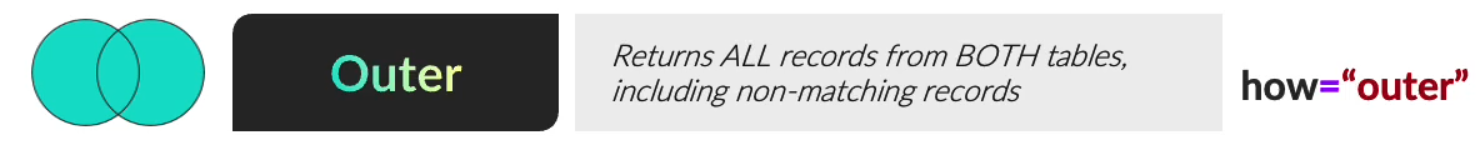

<br>

In [25]:
new_df = df1.merge(df2, 
         on=['date', 'store_nbr'],
         how='outer'
         )
new_df

,id,date,store_nbr,family,sales,onpromotion,transactions
0,NaN,2013-01-01,25,NaN,NaN,NaN,770.0
1,NaN,2013-01-02,1,NaN,NaN,NaN,2111.0
2,NaN,2013-01-02,2,NaN,NaN,NaN,2358.0
3,NaN,2013-01-02,3,NaN,NaN,NaN,3487.0
4,NaN,2013-01-02,4,NaN,NaN,NaN,1922.0
...,...,...,...,...,...,...,...
1107331,3000751.0,2017-08-15,54,POULTRY,59.619,0.0,802.0
1107332,3000752.0,2017-08-15,54,PREPARED FOODS,94.000,0.0,802.0
1107333,3000753.0,2017-08-15,54,PRODUCE,915.371,76.0,802.0
1107334,3000754.0,2017-08-15,54,SCHOOL AND OFFICE SUPPLIES,0.000,0.0,802.0


In [26]:
new_df.isna().sum()

id              52392
date                0
store_nbr           0
family          52392
sales           52392
onpromotion     52392
transactions    28776
dtype: int64

<br><br>

---

## 6. Joins Summary

<br>

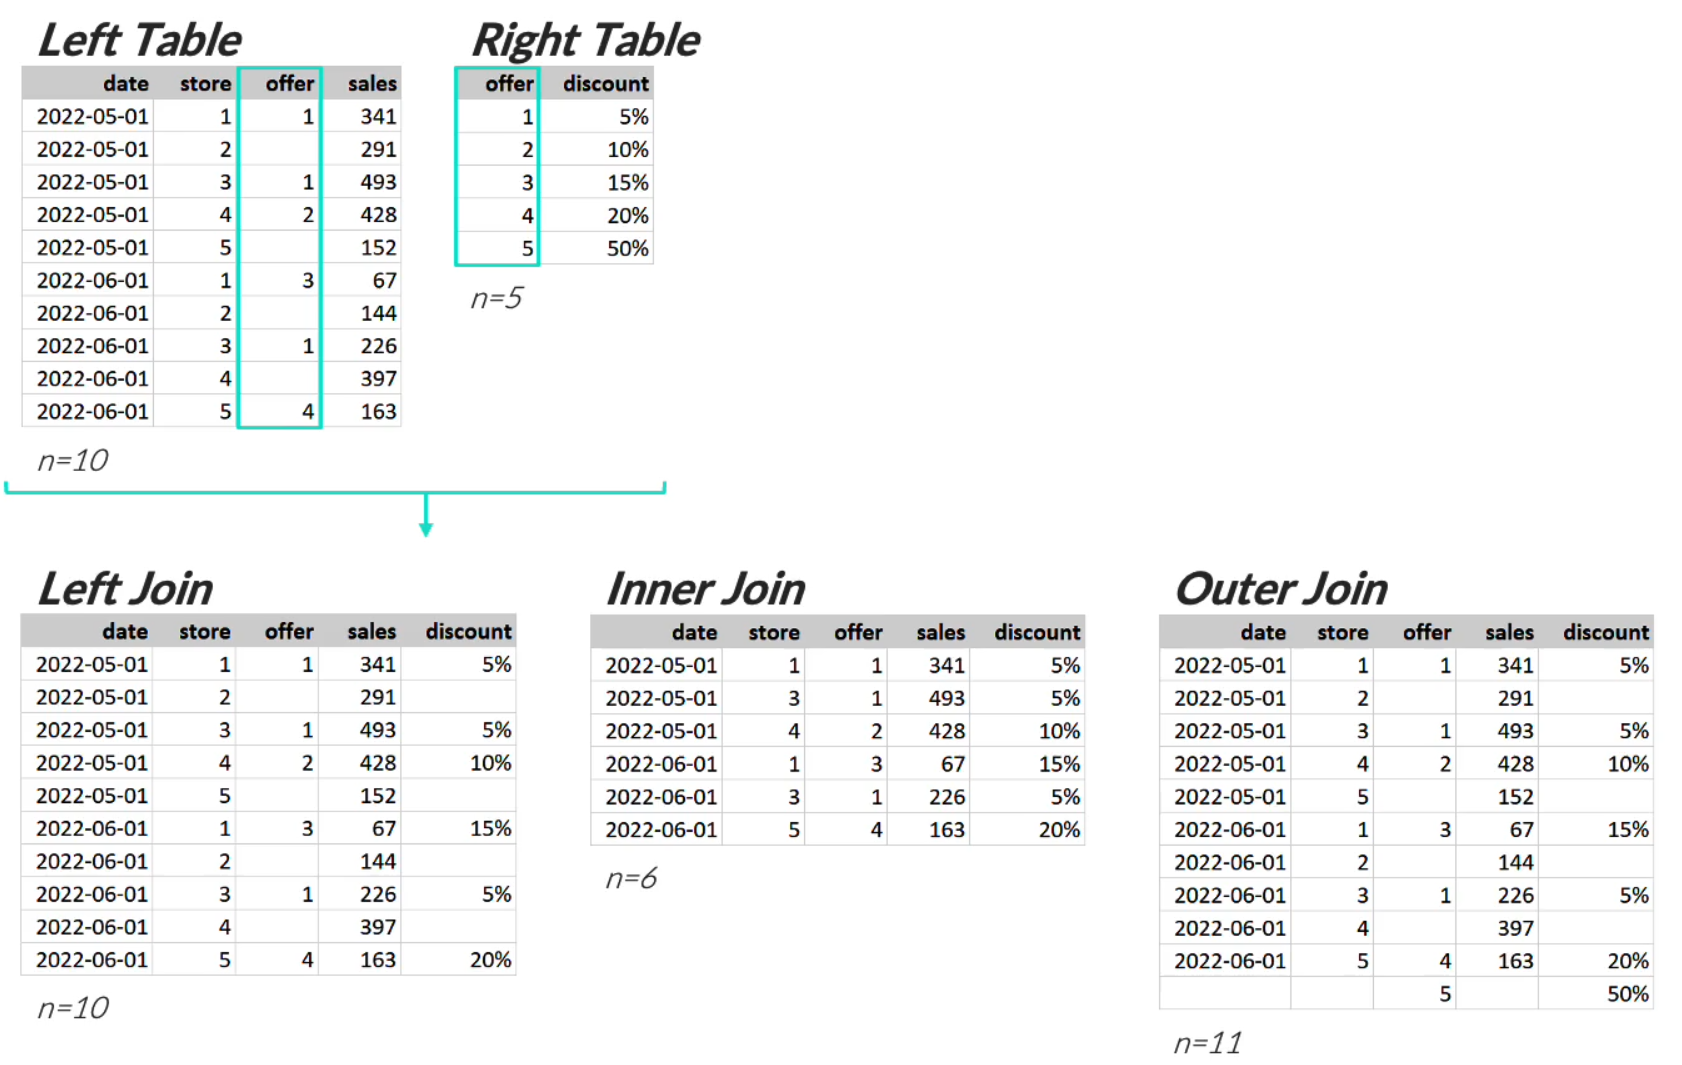

<br>